# Matplotlib: A Gentle Introduction

_A short, practical notebook for beginners._

**What you'll learn**
- The basic anatomy of a Matplotlib figure
- How to make common chart types (line, scatter, bar, histogram)
- Labels, titles, legends, ticks, grids, annotations
- Figure size, resolution, and saving to file
- Quick tips for live demos and further study

## 0) Setup
Run this once to import libraries. If needed, install Matplotlib first.

In [1]:
%pip -q install matplotlib numpy
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
%matplotlib inline
np.random.seed(0)

## 1) Scatter: tracking a metric over time
Imagine **weight tracking** over 14 days. Scatter shows individual observations.

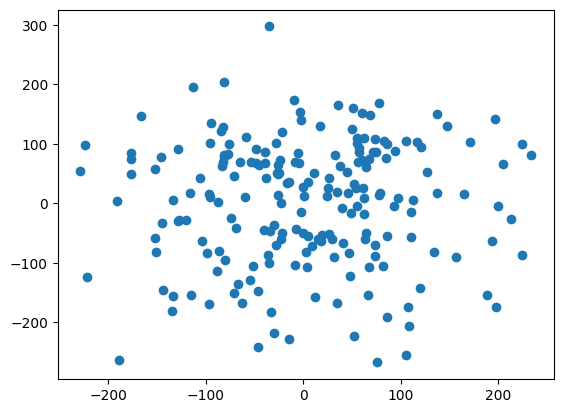

In [32]:
n = 200
x = np.random.randn(n) * 100
y = np.random.randn(n) * 100
plt.figure()
plt.scatter(x, y)
plt.show()

### Scatter with many points — use transparency
When there are thousands of points, reduce visual clutter with `alpha` and smaller sizes.

> **Tip:** `s` controls marker area in points². Try per‑point colors with `c=...` for an extra dimension.

## 2) Line: reveal the trend
Same data, but connected. Add style for emphasis.

In [57]:
from datetime import datetime, timedelta
days = np.array([datetime(2025, 1, 1) + timedelta(days=i) for i in range(14)])
weights = 70 + np.cumsum(np.random.randn(14)*0.2)  # noisy daily measurements

**Line options:** `linewidth`, `linestyle`, `marker`, `alpha`, `markevery`.

## 3) Bar: compare categories (poll example)
Suppose a poll on favorite snack at a meetup: Chips, Fruit, Cookies, Nuts.

In [58]:
labels = ['Chips', 'Fruit', 'Cookies', 'Nuts']
votes = [35, 22, 28, 15]

**Bar options:** `width`, `align`

### Bars vs. Histograms — interpretation matters
- **Bar**: categories (discrete labels). Bar **positions** are arbitrary; **order** can be chosen.
- **Histogram**: numerical variable **binned** into ranges (continuous domain). Bar positions reflect numeric bins.
> So: Bar compares **named groups**; Histogram shows a **distribution**.

## 4) Histogram: distribution, bins, cumulative
Histogram shows how values are distributed across intervals.

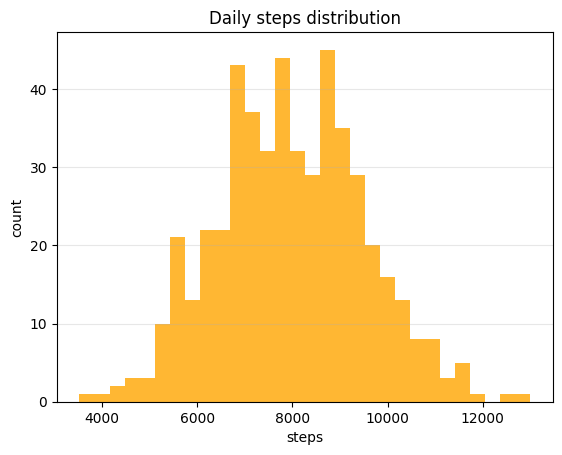

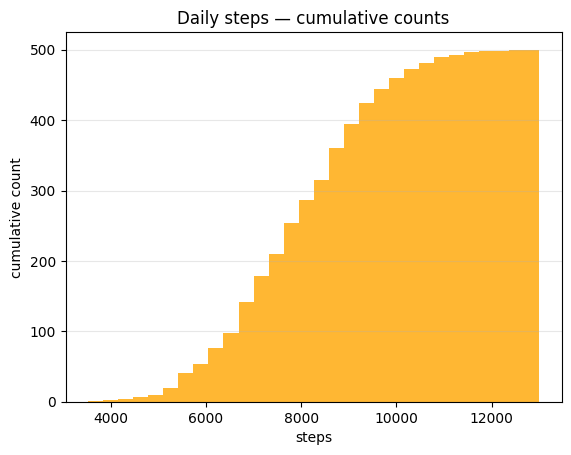

In [59]:
steps = np.random.normal(loc=8000, scale=1500, size=500)
plt.hist(steps, bins=30, color='orange', alpha=0.8)
plt.title('Daily steps distribution')
plt.xlabel('steps')
plt.ylabel('count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Cumulative view (CDF‑like)
plt.hist(steps, bins=30, cumulative=True, color='orange', alpha=0.8)
plt.title('Daily steps — cumulative counts')
plt.xlabel('steps')
plt.ylabel('cumulative count')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Histogram options:** `bins` (number or bin edges), `density=True` (area=1), `cumulative=True`.

## 5) Pie: explode, autopct, use‑cases
Show **part‑to‑whole** with a small number of categories; avoid too many slices.

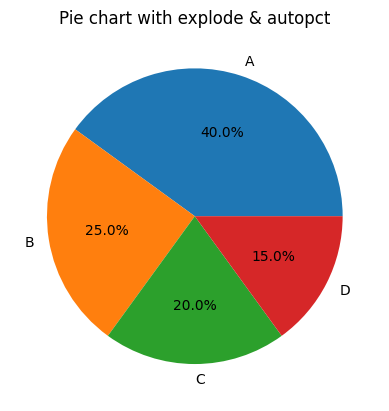

In [61]:
sizes = [40, 25, 20, 15]
labels = ['A', 'B', 'C', 'D']
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Pie chart with explode & autopct')
plt.show()

**Pie options:** `explode` to spotlight a slice, `autopct` to format percentages, `startangle` to rotate.

> **Use‑case tip:** Good for **few parts** and simple messages (e.g., “A is the biggest”). For detailed comparison, prefer bars.

## 6) Plot customization: ticks, labels, titles & more
Make charts readable and on‑brand.

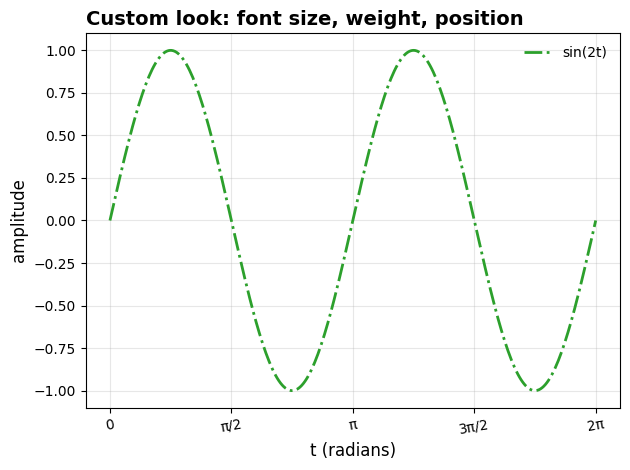

In [65]:
# Example customization on a line plot
t = np.linspace(0, 2*np.pi, 300)
y = np.sin(2*t)
plt.plot(t, y, color='#2ca02c', linestyle='-.', linewidth=2, label='sin(2t)')
plt.title('Custom look: font size, weight, position', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('t (radians)', fontsize=12)
plt.ylabel('amplitude', fontsize=12)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', 'π/2', 'π', '3π/2', '2π'], rotation=10, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', frameon=False)
plt.show()

**Customization ideas**
- Titles: `fontsize`, `fontweight`, `loc` (`'left'|'center'|'right'`)
- Label fonts: `fontsize`, font families via `rcParams['font.family']`
- Ticks: custom positions/labels, rotate, format numbers
- Spines (borders): hide with `plt.gca().spines['top'].set_visible(False)`
- Legend: `loc`, `frameon=False`, custom labels
- Aspect ratio: `plt.axis('equal')` for undistorted shapes
- Global defaults: `plt.rcParams[...]` or style sheets (`plt.style.use('ggplot')`)

## 7) Using colors effectively
- Use named colors or hex codes for brand consistency.
- Use `alpha` for layering and de‑emphasis.
- Keep contrast for readability (lines vs. background).

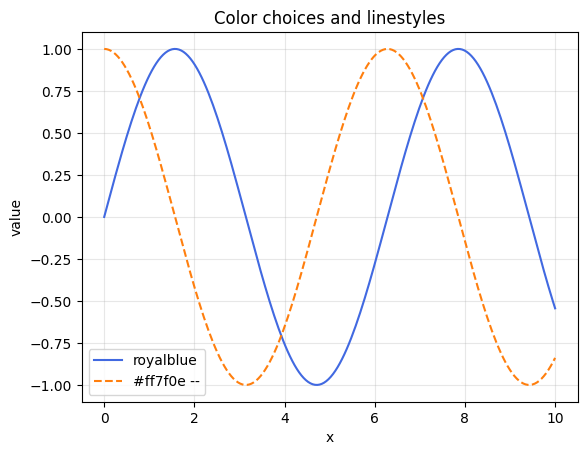

In [12]:
x = np.linspace(0, 10, 200)
plt.plot(x, np.sin(x), color='royalblue', label='royalblue')
plt.plot(x, np.cos(x), color='#ff7f0e', linestyle='--', label='#ff7f0e --')
plt.title('Color choices and linestyles')
plt.xlabel('x')
plt.ylabel('value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8) Exercises (targeted)
1. **Scatter → Line**: Start with random daily measurements. Plot as scatter, then connect as a line with `'g-.'`.
2. **Big Scatter**: Generate 50,000 points; experiment with `s` and `alpha` to reveal structure.
3. **Bar Labels**: Create a bar chart and add value labels above each bar.
4. **Histogram Variants**: Plot `bins=10` and `bins=60`; then a cumulative histogram. Discuss pros/cons.
5. **Pie Emphasis**: Make a pie where the 3rd slice is exploded and percentages are shown with `autopct`.
6. **Customization**: Recreate one figure with custom tick labels, rotated x‑ticks, bold title, and a frameless legend.
7. **Format String**: Use `'r--'` and compare to `color='red', linestyle='--'` to confirm they’re equivalent.

## 9) Quick reference
**What you can change on *every* plot (universal knobs)**
- `plt.title('...')`, `plt.xlabel('...')`, `plt.ylabel('...')`
- Limits: `plt.xlim(a, b)`, `plt.ylim(c, d)`
- Ticks: `plt.xticks([...], rotation=...)`, `plt.yticks([...])`
- Grid: `plt.grid(True)`
- Legend: pass `label=` and call `plt.legend()`
- Save: `plt.savefig('name.png', dpi=300)`
- Colors: `color='red'` or hex `'#1f77b4'`
- Transparency: `alpha=0.3`
- Line width/marker size (where applicable): `linewidth=2`, `markersize=8`

**Plot‑specific**:
- Line/Scatter: `linestyle`, `marker`, `markersize`, `markerfacecolor`, `markeredgecolor`
- Scatter: `s` (size), `c` (per‑point colors), `marker`
- Bar: `width`, `align`, `edgecolor`
- Hist: `bins`, `density`, `cumulative`
- Pie: `explode`, `autopct`, `startangle`, `shadow`

**Markers** (common): `'.'`, `','`, `'o'`, `'v'`, `'^'`, `'<'`, `'>'`, `'s'`, `'p'`, `'*'`, `'h'`, `'H'`, `'+'`, `'x'`, `'D'`, `'d'`, `'|'`, `'_'`

**Linestyles**: `'-'` (solid), `'--'` (dashed), `'-.'` (dash‑dot), `':'` (dotted), `''` (none)

**Colors**: named (`'red'`, `'royalblue'`), hex (`'#ff5733'`), grayscale (`'0.6'`), RGB tuples (`(0.1, 0.2, 0.5)`).

**Format string shorthand** (line color + marker + linestyle): `'r--'`, `'bo'`, `'g-.'` etc.


## 10) Further reading
- Matplotlib Tutorials: https://matplotlib.org/stable/tutorials/index.html
- Pyplot API Summary: https://matplotlib.org/stable/api/pyplot_summary.html
- Marker reference: https://matplotlib.org/stable/api/markers_api.html
- Linestyle reference: https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
- Color reference: https://matplotlib.org/stable/gallery/color/named_colors.html
- What helped me: https://www.youtube.com/watch?v=OZOOLe2imFo (x1.75)